In [1]:
import pandas as pd
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.optim as optim
import glob
import cv2

In [2]:
df = pd.read_csv("/kaggle/input/pid-symbols/train (2).txt", names = ["path"]).reset_index(drop = True)
len(df)

27000

In [36]:
df["fnames"] = df["path"].str.split("/").str[2]
df["fnames"] = df["fnames"].str.split(".").str[0]

In [37]:
df

,path,fnames
0,./images/73_1280_1280.jpg,73_1280_1280
1,./images/142_2560_3200.jpg,142_2560_3200
2,./images/311_1920_4480.jpg,311_1920_4480
3,./images/129_3200_1920.jpg,129_3200_1920
4,./images/4_0_640.jpg,4_0_640
...,...,...
26995,./images/350_3200_1920.jpg,350_3200_1920
26996,./images/493_1280_5760.jpg,493_1280_5760
26997,./images/217_1920_3200.jpg,217_1920_3200
26998,./images/454_1920_5120.jpg,454_1920_5120


In [5]:
x = []
with open(f'/kaggle/input/pid-symbols/labels (2)/{df.fnames[4289]}.txt') as f:
    x.append([line[:-2] for line in f.readlines()])
    

In [6]:
x

[['20 0.066015625 0.729296875 0.05390625 0.0601562',
  '25 0.066015625 0.473828125 0.07421875 0.0742187']]

In [7]:
[i.split(" ") for i in x[0]]

[['20', '0.066015625', '0.729296875', '0.05390625', '0.0601562'],
 ['25', '0.066015625', '0.473828125', '0.07421875', '0.0742187']]

In [8]:
x = [[int(float(val)) if float(val) == int(float(val)) else float(val) for val in i.split()]for i in x[0]]
x

[[20, 0.066015625, 0.729296875, 0.05390625, 0.0601562],
 [25, 0.066015625, 0.473828125, 0.07421875, 0.0742187]]

In [9]:
from PIL import Image
import numpy as np

img = Image.open(f"/kaggle/input/pid-symbols/images (3)/{df.fnames[4289]}.jpg")
img = img.resize((640,640))
print(img.size)
img = np.array(img).astype(np.float32)
img/=255

(640, 640)


In [10]:
img.shape[0]

640

24.999999999999996 447.50001599999996
18.499999999999996 279.500016


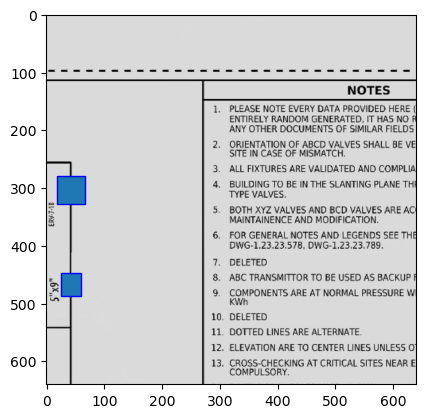

In [11]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as patches
fig, ax = plt.subplots()
for box in x:
    s = img.shape
    print((box[1] - box[3]/2) * s[0], (box[2] - box[4]/2) * s[1])
    bb = patches.Rectangle(
        ((box[1] - box[3]/2) * s[0], (box[2] - box[4]/2) * s[1]), 
        box[3] * s[0],box[4] * s[1], 
        edgecolor="blue")
    ax.add_patch(bb)
 
ax.imshow(img)
plt.show()

In [12]:
trans = T.Compose([T.ToTensor()])

class pidData(Dataset):
    def __init__(self, df, img_dir, ann_dir, img_size, trans = None, train = True):
        self.df = df
        self.transform = trans
        self.train = train
        self.ann_dir = ann_dir
        self.img_dir = img_dir
        self.img_size = img_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img = Image.open(f"{self.img_dir+self.df[idx]}.jpg").convert("RGB")
        img = img.resize((self.img_size, self.img_size))
        img = np.array(img).astype(np.float32)
        img/=255
        if self.transform is not None:
            img = self.transform(img)
        if (self.train == False):
            return img
            
        ann = []
        with open(f'{self.ann_dir+self.df[idx]}.txt') as f:
            ann.append([line[:-2] for line in f.readlines()])
        ann = [[int(float(val)) if float(val) == int(float(val)) else float(val) for val in i.split()]for i in ann[0]]
        boxes = []
        for i in ann:
            if i[3] <= 0 or i[4] <= 0:
                continue
            tmp = []
            tmp.append(float((i[1] - i[3]/2)*self.img_size))
            tmp.append(float((i[2] - i[4]/2)*self.img_size))
            tmp.append(float((i[1] + i[3]/2)*self.img_size))
            tmp.append(float((i[2] + i[4]/2)*self.img_size))
            boxes.append(tmp)
            tmp = []
        target = {}
        target["boxes"] = torch.as_tensor(boxes, dtype = torch.float32)
        target["labels"] = torch.as_tensor([j[0] for j in ann], dtype=torch.int64)
        
        
        return img, target

In [38]:
x = []
empty_files = []
for i in range(len(df)):
    with open(f'/kaggle/input/pid-symbols/labels (2)/{df.fnames[i]}.txt') as f:
        x.append([line[:-2] for line in f.readlines()])
    if len(x[0]) == 0:
        empty_files.append(df.fnames[i])
    x = []

In [39]:
df = df[~df['fnames'].isin(empty_files)]

In [24]:
ex = df.sample(5).fnames.values
ex

array(['8_1280_1280', '48_1920_1920', '57_0_1280', '43_1920_3840',
       '243_1280_640'], dtype=object)

In [39]:
samp = pidData(list(ex), "/kaggle/input/pid-symbols/images (3)/", "/kaggle/input/pid-symbols/labels (2)/", 320, trans = trans)

In [13]:
def custom_collate(batch):
    return tuple(zip(*batch))

In [70]:
dl = DataLoader(samp, batch_size=5, collate_fn=custom_collate)

In [71]:
# batch = next(iter(dl))
X, y = next(iter(dl))

In [72]:
X[0].shape, y[0]["boxes"].shape, y[0]["labels"].shape

(torch.Size([3, 320, 320]), torch.Size([12, 4]), torch.Size([13]))

In [73]:
y[0]

{'boxes': tensor([[ 38.7500,  42.5000,  70.5000,  74.2500],
         [ 83.0000,  84.5000, 104.7500, 101.2500],
         [218.0000,  86.0008, 246.2500, 100.9992],
         [118.2500, 251.8000, 133.5000, 274.2000],
         [145.5000, 221.7501, 174.5000, 243.2499],
         [118.2500, 112.2501, 133.5000, 134.7499],
         [  0.7500,  85.7500,  21.2500, 101.5000],
         [260.7500, 192.5001, 276.0000, 214.9999],
         [260.0000, 121.2508, 276.0000, 142.2492],
         [ 11.5000, 228.7500,  35.7500, 244.0000],
         [154.5000, 157.0008, 179.7500, 171.9992],
         [189.2500, 105.2508, 204.7500, 128.2492]]),
 'labels': tensor([32, 11,  6,  4, 10, 11,  1, 11,  1,  5, 15, 12,  2])}

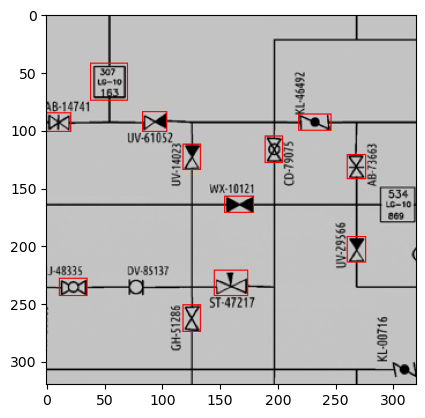

In [45]:
fig, ax = plt.subplots()
image = X[0].permute(1, 2, 0).detach().numpy()
image_with_rect = image.copy()

for x in y[0]['boxes']:
    cv2.rectangle(image_with_rect, (int(x[0].numpy()), int(x[1].numpy())), (int(x[2].numpy()), int(x[3].numpy())), (222, 0, 0), 1)
    
ax.imshow(image_with_rect)
plt.show()

In [14]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True, pretrained_backbone=True)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weigh

In [291]:
train = df.head(500).fnames.values

In [292]:
len(train)

500

In [293]:
train_ds = pidData(list(train), "/kaggle/input/pid-symbols/images (3)/", "/kaggle/input/pid-symbols/labels (2)/", 640, trans = trans)
train_dl = DataLoader(train_ds, batch_size=5, collate_fn=custom_collate, shuffle=False)

In [294]:
X, y = next(iter(train_dl))

In [295]:
X[0].shape, y[0]["boxes"].shape, y[0]["labels"].shape

(torch.Size([3, 640, 640]), torch.Size([12, 4]), torch.Size([12]))

In [15]:
num_classes = 33
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
optimizer = optim.SGD(model.parameters(), lr = 2e-4, momentum=0.9, weight_decay=1e-4)
num_epochs = 30

In [21]:
checkpoint = torch.load('/kaggle/input/pandid-trained/pandid_rcnn.t7')
model.load_state_dict(checkpoint['state_dict'])
optimizer.load_state_dict(checkpoint['optimizer'])
epochs = checkpoint['epoch']

In [304]:
# for images, targets in train_dl:
#     if str(targets[0]["boxes"].shape) == "torch.Size([0])":
#         print(targets)
#         break

In [303]:
itr = 1
model.to(device)
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for images, targets in train_dl:
        
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)   ##Return the loss
        
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.cpu().detach().numpy()
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if itr % 50 == 0:
            print(f"Iteration #{itr} loss: {loss_value}")

        itr += 1
    

    print(f"Epoch #{epoch} loss: {epoch_loss}")

Iteration #50 loss: 4.612180709838867
Iteration #100 loss: 4.612180709838867
Epoch #0 loss: 179.96935260295868
Iteration #150 loss: 4.612180709838867
Iteration #200 loss: 4.612180709838867
Epoch #1 loss: 162.96206444501877
Iteration #250 loss: 4.612180709838867
Iteration #300 loss: 4.612180709838867
Epoch #2 loss: 154.04111069440842
Iteration #350 loss: 4.612180709838867
Iteration #400 loss: 4.612180709838867
Epoch #3 loss: 143.12963271141052
Iteration #450 loss: 4.612180709838867
Iteration #500 loss: 4.612180709838867
Epoch #4 loss: 128.0076326727867
Iteration #550 loss: 4.612180709838867
Iteration #600 loss: 4.612180709838867
Epoch #5 loss: 108.92003440856934
Iteration #650 loss: 4.612180709838867
Iteration #700 loss: 4.612180709838867
Epoch #6 loss: 91.17915534973145
Iteration #750 loss: 4.612180709838867
Iteration #800 loss: 4.612180709838867
Epoch #7 loss: 77.72332215309143
Iteration #850 loss: 4.612180709838867
Iteration #900 loss: 4.612180709838867
Epoch #8 loss: 68.771456092596

In [364]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [40]:
val = [df.iloc[1001].fnames]
val_ds = pidData(val, "/kaggle/input/pid-symbols/images (3)/", "/kaggle/input/pid-symbols/labels (2)/", 320, trans = trans)
val_dl = DataLoader(val_ds, batch_size=1, shuffle=False)

In [41]:
X, y= next(iter(val_dl))

In [42]:
X.shape

torch.Size([1, 3, 320, 320])

In [43]:
y

{'boxes': tensor([[[ 57.0000, 189.5000,  70.7500, 196.7500],
          [ 37.7500, 259.7500,  51.2500, 273.5000]]]),
 'labels': tensor([[21, 15]])}

In [44]:
model.to(device)
model.eval()
out = model(list(X.to(device)))

In [45]:
out_boxes = out[0]["boxes"]
out_labels = out[0]["labels"]
out_scores = out[0]["scores"]

In [46]:
out_scores

tensor([0.9698, 0.7351, 0.2146, 0.2019, 0.1285, 0.1277, 0.1260, 0.1008, 0.0896,
        0.0891, 0.0646, 0.0635, 0.0634], device='cuda:0',
       grad_fn=<IndexBackward0>)

In [47]:
out_boxes = out_boxes[out_scores >= 0.45].data.cpu().numpy().astype(np.int32)
out_labels = out_labels[out_scores >= 0.45].data.cpu().numpy().astype(np.int32)

In [48]:
out_boxes

array([[ 57, 189,  71, 196],
       [ 38, 259,  51, 274]], dtype=int32)

In [49]:
out_labels

array([21, 15], dtype=int32)

In [50]:
y

{'boxes': tensor([[[ 57.0000, 189.5000,  70.7500, 196.7500],
          [ 37.7500, 259.7500,  51.2500, 273.5000]]]),
 'labels': tensor([[21, 15]])}

In [51]:
og_boxes  = y["boxes"].squeeze().data.cpu().numpy().astype(np.int32)
og_labels  = y["labels"].squeeze().data.cpu().numpy().astype(np.int32)

In [52]:
og_boxes

array([[ 57, 189,  70, 196],
       [ 37, 259,  51, 273]], dtype=int32)

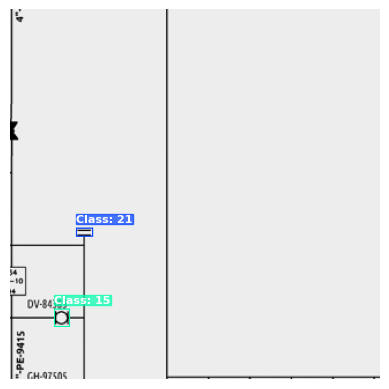

In [53]:
def generate_color_map(num_classes):
    colors = []
    for i in range(num_classes):
        hue = i / num_classes
        rgb = plt.cm.hsv(hue)[:3]
        colors.append(tuple(np.array(rgb) * 255))
    return colors

num_classes = 33
class_colors = generate_color_map(num_classes)


fig, ax = plt.subplots()

image = X[0].permute(1, 2, 0).detach().numpy()
image_with_rect = image.copy()
for x, label in zip(out_boxes, out_labels):
    x_min, y_min, x_max, y_max = x
    color = class_colors[label.item()]
    color = tuple(c / 255.0 for c in color)
    cv2.rectangle(image_with_rect, (x_min, y_min), (x_max, y_max), color, 1)
    
    text = f"Class: {label.item()}"
    ax.text(x_min, y_min - 5, text, color='white', fontsize=8, weight='bold', 
            bbox=dict(facecolor=color, edgecolor=color, pad=0, alpha=0.7))

ax.imshow(image_with_rect)
plt.axis('off')
plt.show()

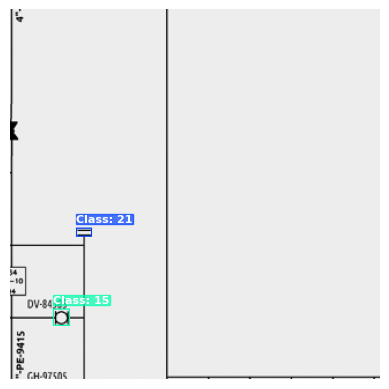

In [56]:
fig, ax = plt.subplots()

image = X[0].permute(1, 2, 0).detach().numpy()
image_with_rect = image.copy()
for x, label in zip(og_boxes, og_labels):
    x_min, y_min, x_max, y_max = x
    color = class_colors[label.item()]
    color = tuple(c / 255.0 for c in color)
    cv2.rectangle(image_with_rect, (x_min, y_min), (x_max, y_max), color, 1)
    
    text = f"Class: {label.item()}"
    ax.text(x_min, y_min - 5, text, color='white', fontsize=8, weight='bold', 
            bbox=dict(facecolor=color, edgecolor=color, pad=0, alpha=0.7))

ax.imshow(image_with_rect)
plt.axis('off')
plt.show()

In [421]:
state = {
        'epoch': num_epochs,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict()
        }
savepath = './pandid_rcnn.t7'
torch.save(state,savepath)

In [405]:
# fig, ax = plt.subplots()
# image = X[0].permute(1, 2, 0).detach().numpy()
# image_with_rect = image.copy()

# for x in out_boxes:
#     cv2.rectangle(image_with_rect, (x[0], x[1]), (x[2], x[3]), (222, 0, 0), 1)
    
# ax.imshow(image_with_rect)
# plt.show()